In [ ]:
# Comment out Colab-specific code - uncomment if running on Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install torch torch_geometric scikit-learn networkx matplotlib

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

device = "cpu"

In [ ]:
train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")
features_df = pd.read_csv("NUSW-NB15_features.csv", encoding='latin1')

print(train_df.shape, test_df.shape)

(82332, 45) (175341, 45)


In [96]:
print(train_df.info())
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [97]:
def preprocess(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Drop id if exists
    if 'id' in train_df.columns:
        train_df.drop(columns=['id'], inplace=True)
        test_df.drop(columns=['id'], inplace=True)

    # Handle missing values
    for col in train_df.columns:
        if train_df[col].dtype == 'object':
            train_df[col].fillna(train_df[col].mode()[0], inplace=True)
            test_df[col].fillna(train_df[col].mode()[0], inplace=True)
        else:
            train_df[col].fillna(train_df[col].mean(), inplace=True)
            test_df[col].fillna(train_df[col].mean(), inplace=True)

    # Ordinal Encoding
    cat_cols = ['proto', 'service', 'state']
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    train_df[cat_cols] = encoder.fit_transform(train_df[cat_cols])
    test_df[cat_cols] = encoder.transform(test_df[cat_cols])

    return train_df, test_df, encoder

In [98]:
train_df, test_df, encoder = preprocess(train_df, test_df)

/tmp/ipykernel_718/712047224.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)
/tmp/ipykernel_718/712047224.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [99]:
X_train = train_df.drop(columns=['label', 'attack_cat'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label', 'attack_cat'])
y_test = test_df['label']

In [100]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float)
X_test = torch.tensor(X_test, dtype=torch.float)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

In [101]:
def create_graph_with_features(df, X):
    G = nx.Graph()
    num_nodes = len(df)

    for i in range(num_nodes):
        G.add_node(i)

    # Group by proto
    proto_groups = df.groupby('proto').groups
    service_groups = df.groupby('service').groups

    # Connect nodes in same proto
    for group in proto_groups.values():
        nodes = list(group)
        for i in range(len(nodes) - 1):
            u, v = nodes[i], nodes[i+1]
            edge_feat = np.abs(X[u].numpy() - X[v].numpy())
            G.add_edge(u, v, edge_attr=edge_feat)

    # Connect nodes in same service
    for group in service_groups.values():
        nodes = list(group)
        for i in range(len(nodes) - 1):
            u, v = nodes[i], nodes[i+1]
            edge_feat = np.abs(X[u].numpy() - X[v].numpy())
            G.add_edge(u, v, edge_attr=edge_feat)

    return G

In [102]:
def to_pyg(df, X, y):
    G = create_graph_with_features(df, X)

    edges = []
    edge_attrs = []

    for u, v, data in G.edges(data=True):
        edges.append([u, v])
        edge_attrs.append(data['edge_attr'])

    edge_index = torch.tensor(edges).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)

    return Data(
        x=X,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

In [103]:
train_data = to_pyg(train_df, X_train, y_train)
test_data = to_pyg(test_df, X_test, y_test)

print(train_data)

Data(x=[82332, 42], edge_index=[2, 116611], edge_attr=[116611, 42], y=[82332])


In [104]:
class GCN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, 16)
        self.conv2 = GCNConv(16, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)

        return x

In [105]:
model = GCN(X_train.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [106]:
losses = []

for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    out = model(train_data)
    loss = criterion(out, train_data.y)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 1.0354
Epoch 2, Loss: 0.8050
Epoch 3, Loss: 0.6595
Epoch 4, Loss: 0.5913
Epoch 5, Loss: 0.5586
Epoch 6, Loss: 0.5400
Epoch 7, Loss: 0.5266
Epoch 8, Loss: 0.5180
Epoch 9, Loss: 0.5061
Epoch 10, Loss: 0.4938
Epoch 11, Loss: 0.4838
Epoch 12, Loss: 0.4699
Epoch 13, Loss: 0.4580
Epoch 14, Loss: 0.4418
Epoch 15, Loss: 0.4295
Epoch 16, Loss: 0.4107
Epoch 17, Loss: 0.3983
Epoch 18, Loss: 0.3849
Epoch 19, Loss: 0.3728
Epoch 20, Loss: 0.3603
Epoch 21, Loss: 0.3491
Epoch 22, Loss: 0.3401
Epoch 23, Loss: 0.3307
Epoch 24, Loss: 0.3209
Epoch 25, Loss: 0.3119
Epoch 26, Loss: 0.3061
Epoch 27, Loss: 0.2970
Epoch 28, Loss: 0.2897
Epoch 29, Loss: 0.2819
Epoch 30, Loss: 0.2743
Epoch 31, Loss: 0.2680
Epoch 32, Loss: 0.2616
Epoch 33, Loss: 0.2560
Epoch 34, Loss: 0.2502
Epoch 35, Loss: 0.2445
Epoch 36, Loss: 0.2405
Epoch 37, Loss: 0.2347
Epoch 38, Loss: 0.2307
Epoch 39, Loss: 0.2266
Epoch 40, Loss: 0.2214
Epoch 41, Loss: 0.2183
Epoch 42, Loss: 0.2144
Epoch 43, Loss: 0.2104
Epoch 44, Loss: 0.20

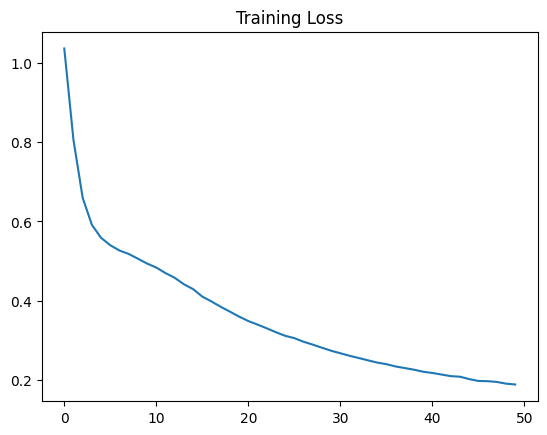

In [107]:
plt.plot(losses)
plt.title("Training Loss")
plt.show()

In [108]:
model.eval()

with torch.no_grad():
    out = model(test_data)
    preds = out.argmax(dim=1)

y_true = y_test.numpy()
y_pred = preds.numpy()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.9146862399552871
Precision: 0.9657083199486026
Recall: 0.9068551461777595
F1: 0.9353568789459356
Confusion Matrix:
 [[ 52157   3843]
 [ 11116 108225]]


In [109]:
def get_risk_score(idx):
    model.eval()
    with torch.no_grad():
        out = model(test_data)
        probs = torch.softmax(out, dim=1)
        return probs[idx][1].item()

In [110]:
def analyzer(score):
    if score > 0.8:
        return "HIGH RISK 🚨"
    elif score > 0.5:
        return "SUSPICIOUS ⚠️"
    else:
        return "NORMAL ✅"

In [111]:
cat_cols = ['proto', 'service', 'state']

def decode(col_idx, value):
    return encoder.categories_[col_idx][int(value)]

In [112]:
for i in range(5):
    row = test_df.iloc[i]

    proto = decode(0, row['proto'])
    service = decode(1, row['service'])
    state = decode(2, row['state'])

    score = get_risk_score(i)
    decision = analyzer(score)

    print(f"""
Traffic Flow:
Protocol: {proto.upper()}
Service: {service}
State: {state}
Attack Type: {row['attack_cat']}

Risk Score: {score:.4f}
Decision: {decision}
---------------------------
""")


Traffic Flow:
Protocol: TCP
Service: -
State: FIN
Attack Type: Normal

Risk Score: 0.7064
Decision: SUSPICIOUS ⚠️
---------------------------


Traffic Flow:
Protocol: TCP
Service: -
State: FIN
Attack Type: Normal

Risk Score: 0.7149
Decision: SUSPICIOUS ⚠️
---------------------------


Traffic Flow:
Protocol: TCP
Service: -
State: FIN
Attack Type: Normal

Risk Score: 0.7425
Decision: SUSPICIOUS ⚠️
---------------------------


Traffic Flow:
Protocol: TCP
Service: ftp
State: FIN
Attack Type: Normal

Risk Score: 0.8312
Decision: HIGH RISK 🚨
---------------------------


Traffic Flow:
Protocol: TCP
Service: -
State: FIN
Attack Type: Normal

Risk Score: 0.7777
Decision: SUSPICIOUS ⚠️
---------------------------



In [113]:
test_df['pred'] = y_pred

for attack in test_df['attack_cat'].unique():
    sub = test_df[test_df['attack_cat'] == attack]
    acc = (sub['label'] == sub['pred']).mean()
    print(f"{attack}: {acc:.4f}")

Normal: 0.9314
Backdoor: 0.9164
Analysis: 0.8265
Fuzzers: 0.7428
Shellcode: 0.8032
Reconnaissance: 0.8462
Exploits: 0.9085
DoS: 0.9201
Worms: 0.8692
Generic: 0.9986


In [114]:
attack_risk = {}

for attack in test_df['attack_cat'].unique():
    idxs = test_df[test_df['attack_cat'] == attack].index[:100]
    scores = [get_risk_score(i) for i in idxs]
    attack_risk[attack] = np.mean(scores)

print(attack_risk)

{'Normal': np.float64(0.3805089679453522), 'Backdoor': np.float64(0.9099377876520157), 'Analysis': np.float64(0.8131569451093674), 'Fuzzers': np.float64(0.5840201272815466), 'Shellcode': np.float64(0.6670583199709654), 'Reconnaissance': np.float64(0.7025339306145907), 'Exploits': np.float64(0.800026318654418), 'DoS': np.float64(0.8424805290997028), 'Worms': np.float64(0.7686028135195374), 'Generic': np.float64(0.9835470169782639)}
